In [6]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from math import sqrt, sin, cos, hypot, atan2#, abs

#hypot вернет гипотенузу

In [7]:
#1

In [8]:
class Line:

    def __init__(self, a, b, c):
        
        self.a = a
        self.b = b
        self.c = c

        self.l = np.array([a, b, c])
        self.N = np.array([a, b])
        self.V = np.array([-b, a])
        self.n = self.N / self.norm()
        self.v = self.V / self.norm()
        self.d = self.c / self.norm()
        self.P0 = -self.d * self.n #перпендикуляр из начала координат на прямую
        #self.c_a = -c / a
        #self.c_b = -c / b
        #self.k = -a / b

    def __repr__(self):
        return f"""
        a = {self.l[0]},
        b = {self.l[1]},
        c = {self.l[2]},
        n = {self.n},
        v = {self.v},
        P_0 = {self.P0},
        """

        #c_a = {self.c_a},
        #c_b = {self.c_b},
        #k = {self.k},
    

    @classmethod
    def intercept_form(cls, c_a, c_b):
        "в отрезках"
        "c_b x + c_a y - c_a*c_b = 0"
        return cls(c_b, c_a, -c_a*c_b)

    @classmethod
    def point_slope_form(cls, k, c_b):
        "y - kx - c_b = 0"
        return cls(-k, 1, -c_b)

    @classmethod
    def from_two_points(cls, P1, P2):
        #Возвращает перекрестное произведение двух (массивов) векторов.
        l = np.cross(P1, P2)
        a, b, c = l
        return cls(a, b, c)

    @classmethod
    def parametric_form(cls, V, P):
        Vx, Vy = V
        n = np.array([-Vy, Vx])
        n /= np.linalg.norm(n)
        nx, ny = n
        d = -np.dot(n, P)
        return cls(nx, ny, d)

    def get_point(self, t):
        return self.P0 + t * np.v

    def norm(self):
        return hypot(self.a, self.b)

    def theta(self):
        nx, ny = self.n
        return atan2(ny, nx)

    def slope(self): #k
        return - self.a / self.b      

In [9]:
#2

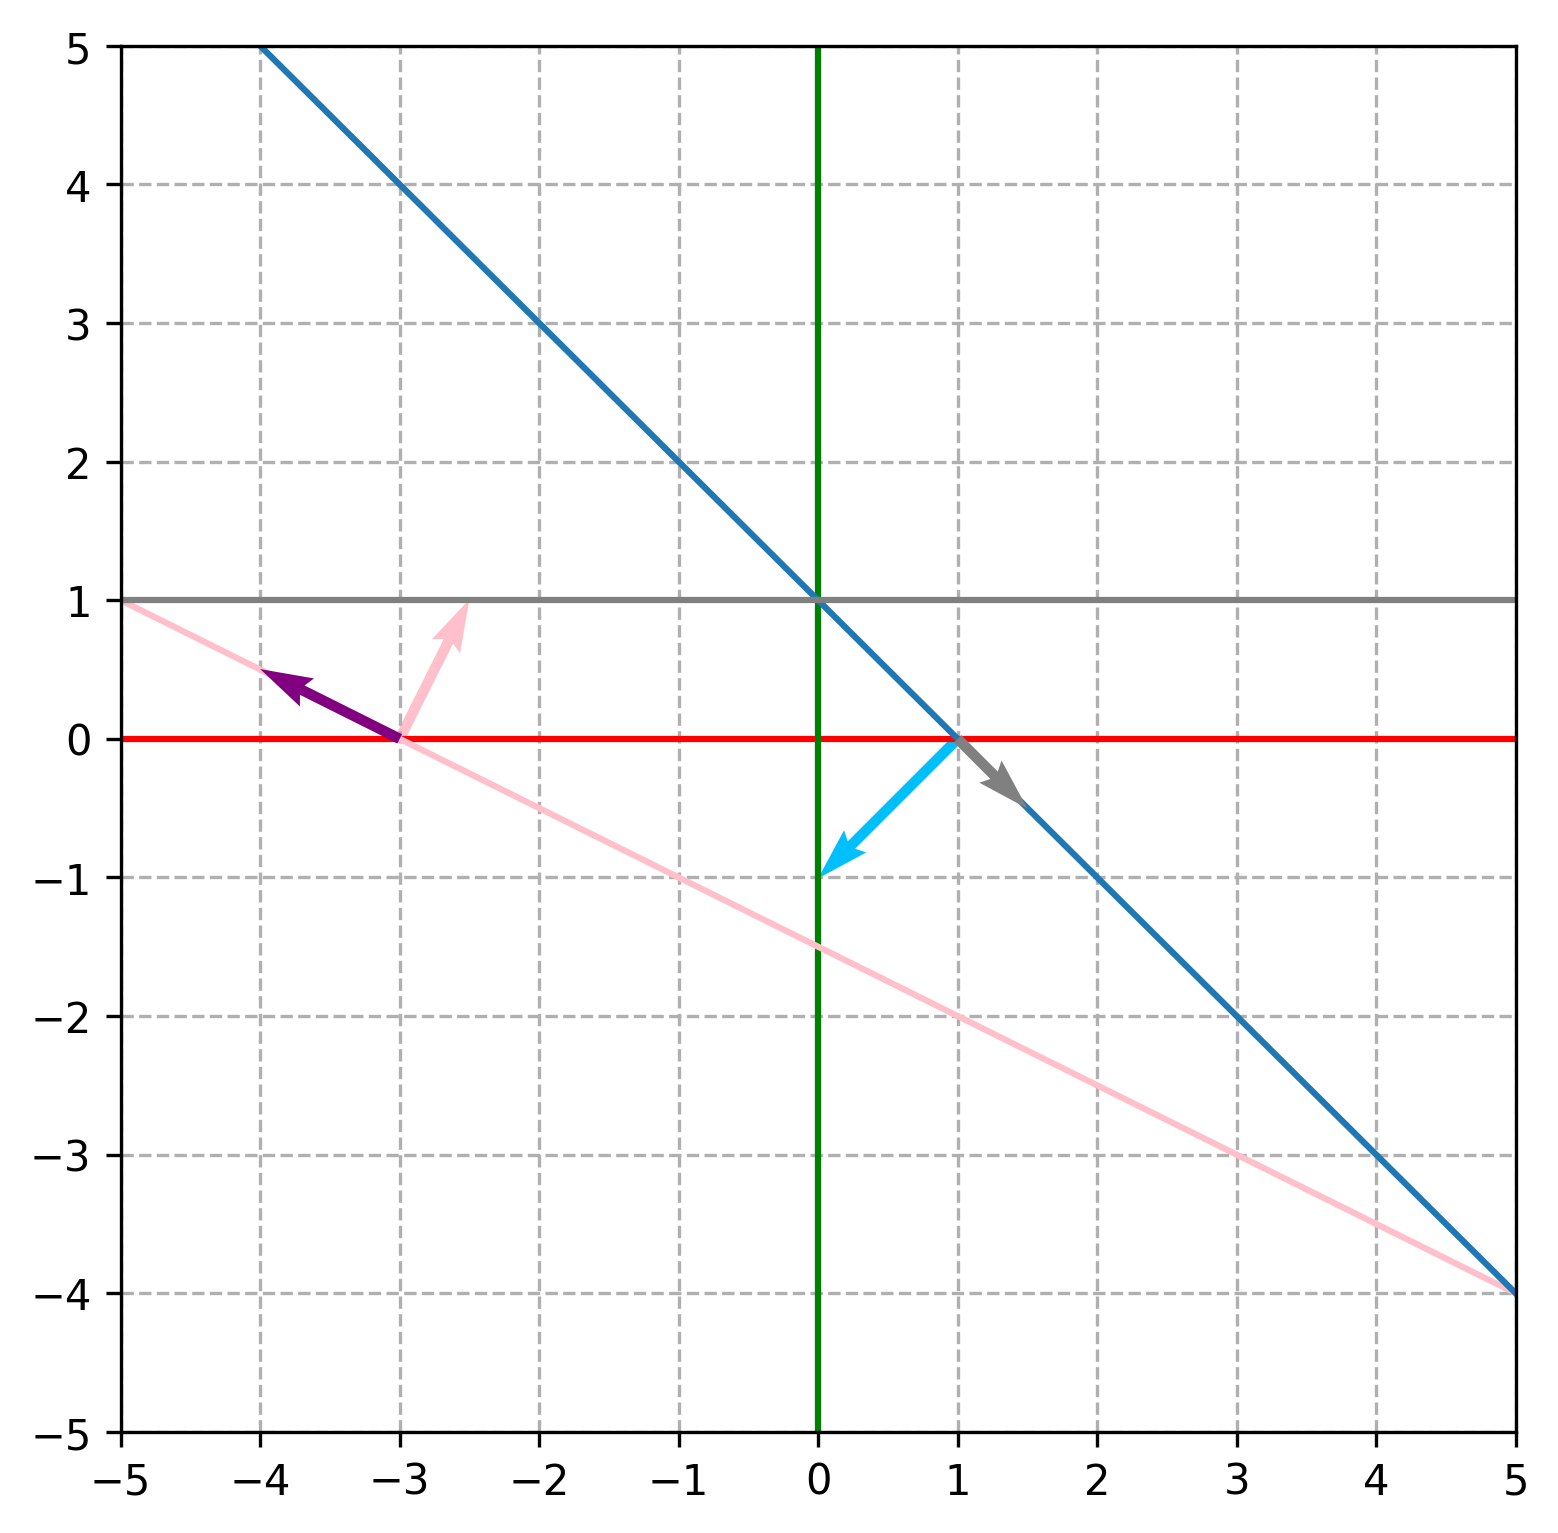

In [13]:
fig01 = plt.figure(num = 1, figsize = (6, 6), dpi = 300)
ax01 = fig01.add_subplot(1, 1, 1)

ax01.grid(True, ls = "--")

ax01.set(xlim = (-5, 5), ylim = (-5, 5))
ax01.set_xticks(np.arange(-5, 6, 1))
ax01.set_yticks(np.arange(-5, 6, 1))

ax01.axline(xy1=(0, 0), xy2=(1, 0), color="red")
ax01.axline(xy1=(0, 0), xy2=(0, 1), color="green")

l1 = Line(1, 2, 3)
l2 = Line.from_two_points(np.array([1, 0, 1]), np.array([0, 1, 1])) 
l3 = Line.from_two_points(np.array([1, 0, 0]), np.array([0, 1, 1])) 

ax01.axline(xy1=l1.P0, slope=l1.slope(), color = "pink")
ax01.axline(xy1=l2.P0, slope=l2.slope())
ax01.axline(xy1=l3.P0, slope=l3.slope(), color  = "gray")


#norm
ax01.quiver(-l1.c/l1.a, 0, l1.N[0], l1.N[1], color='#FFC0CB', scale = 20) 
ax01.quiver(-l2.c/l2.a, 0, l2.N[0], l2.N[1], color='#00BFFF', scale = 10)

#napr
ax01.quiver(-l1.c/l1.a, 0, l1.V[0], l1.V[1], color = 'purple', scale = 20, zorder = 10)
ax01.quiver(-l2.c/l2.a, 0, l2.V[0], l2.V[1], color = 'grey', scale = 20, zorder = 10)

In [ ]:
#3

In [14]:
from numpy.random import randint

In [20]:
tochki = np.random.randint(-4, 4, size=(2, 10))
tochki

array([[ 1, -1, -2,  3, -2, -3,  3,  2, -2, -1],
       [ 3, -4, -1, -3, -4, -2,  2,  1, -3,  1]])

In [21]:
m = np.random.randint(-5, 5, size=(1, 3))
m

array([[ 1,  4, -3]])

In [22]:
m[0][0]

1

In [23]:
l1 = Line(m[0][0], m[0][1], m[0][2])

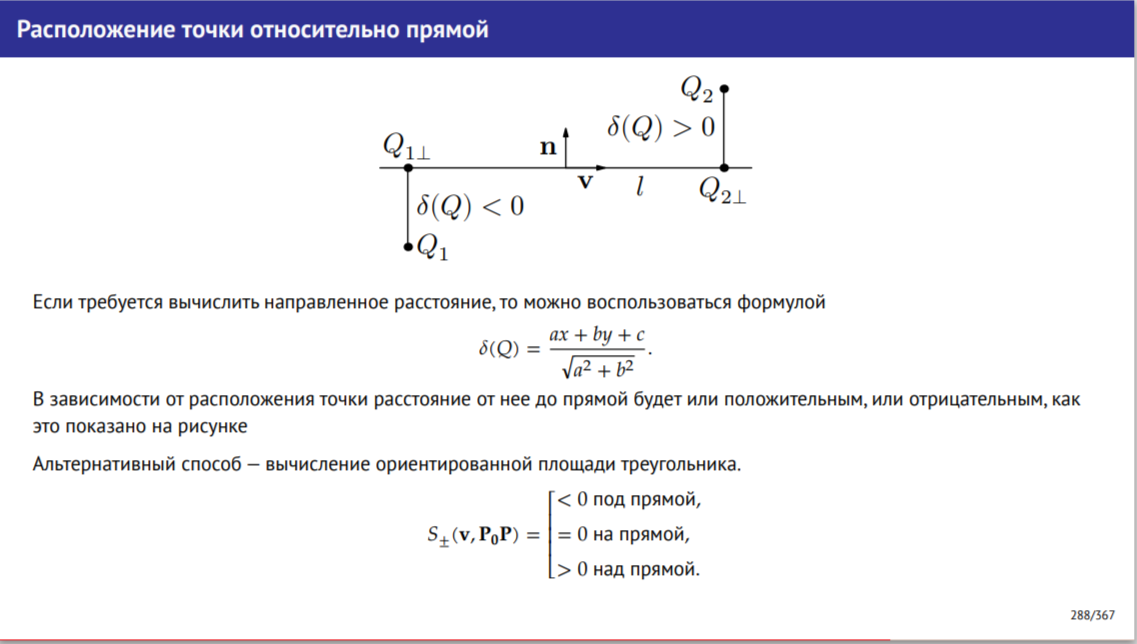

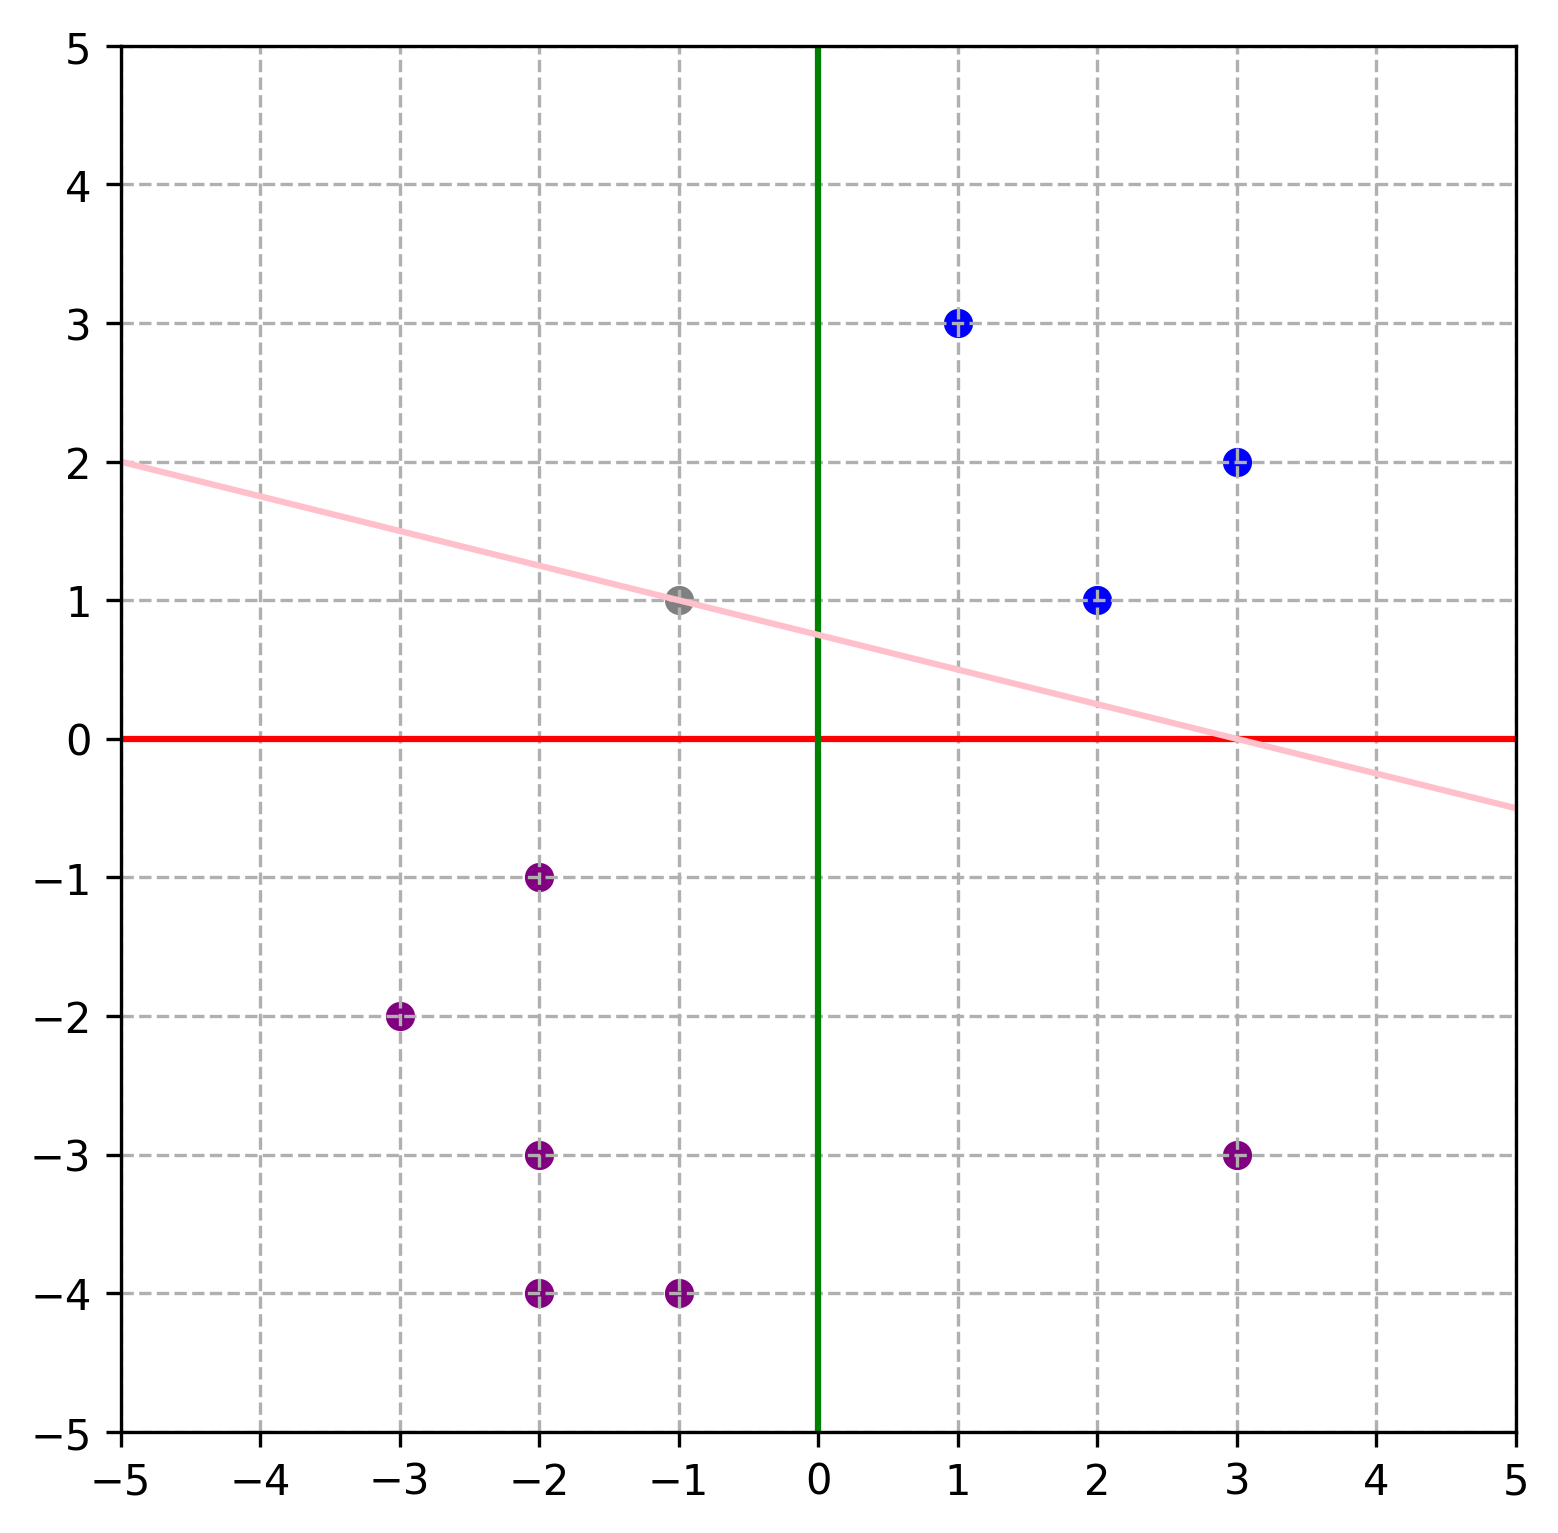

In [26]:
fig01 = plt.figure(num = 2, figsize = (6, 6), dpi = 300)
ax01 = fig01.add_subplot(1, 1, 1)

ax01.grid(True, ls = "--")

ax01.set(xlim = (-5, 5), ylim = (-5, 5))
ax01.set_xticks(np.arange(-5, 6, 1))
ax01.set_yticks(np.arange(-5, 6, 1))

ax01.axline(xy1=(0, 0), xy2=(1, 0), color="red")
ax01.axline(xy1=(0, 0), xy2=(0, 1), color="green")

for t in tochki.T:
    x, y = t
    
    qwerty = (l1.a*x+l1.b*y+l1.c)#/sqrt(l1.a*l1.a + l1.b*l1.b)
# если число не целое - то равенстов нулю не точно
    if qwerty > 0:
        color = "blue"
    elif abs(qwerty) < 0.001:
        color = "gray"
    else:
        color = "purple"
    ax01.scatter(x, y, color=color)

ax01.axline(xy1=l1.P0, slope=l1.slope(), color = "pink")

In [893]:
#4

In [30]:
#mnogoug = np.random.randint(-3, 3, size=(2, 4))
#mnogoug
#vertices = [(mnogoug[0][0], mnogoug[1][0]), (mnogoug[0][1], mnogoug[1][1]), (mnogoug[0][2], mnogoug[1][2]), (mnogoug[0][3], mnogoug[1][3])]
#vertices
#mnogoug1 = np.random.randint(1, 4, size=(2, 4))
#mnogoug1
#vertices1 = [(mnogoug1[0][0], mnogoug1[1][0]), (mnogoug1[0][1], mnogoug1[1][1]), (mnogoug1[0][2], mnogoug1[1][2]), (mnogoug1[0][3], mnogoug1[1][3])]
#vertices1

In [31]:
def mnogoug_prav(n, r):
    angles = np.linspace(0, 2*np.pi, n, endpoint=False)
    x = r * np.cos(angles)
    y = r * np.sin(angles)
    vertices = np.column_stack((x, y))
    return vertices

In [43]:
m = np.random.randint(-5, 5, size=(1, 3))
m

array([[ 4, -4,  2]])

In [44]:
#l4 = Line(-4, 4, -3)

In [45]:
l4 = Line(m[0][0], m[0][1], m[0][2])

In [49]:
l4 = Line(-2, 2, 7)

In [50]:
import matplotlib.patches as mpatches

[[ 2.0000000e+00  0.0000000e+00]
 [ 1.2246468e-16  2.0000000e+00]
 [-2.0000000e+00  2.4492936e-16]
 [-3.6739404e-16 -2.0000000e+00]]
[ 1.75 -1.75]
2.474873734152916


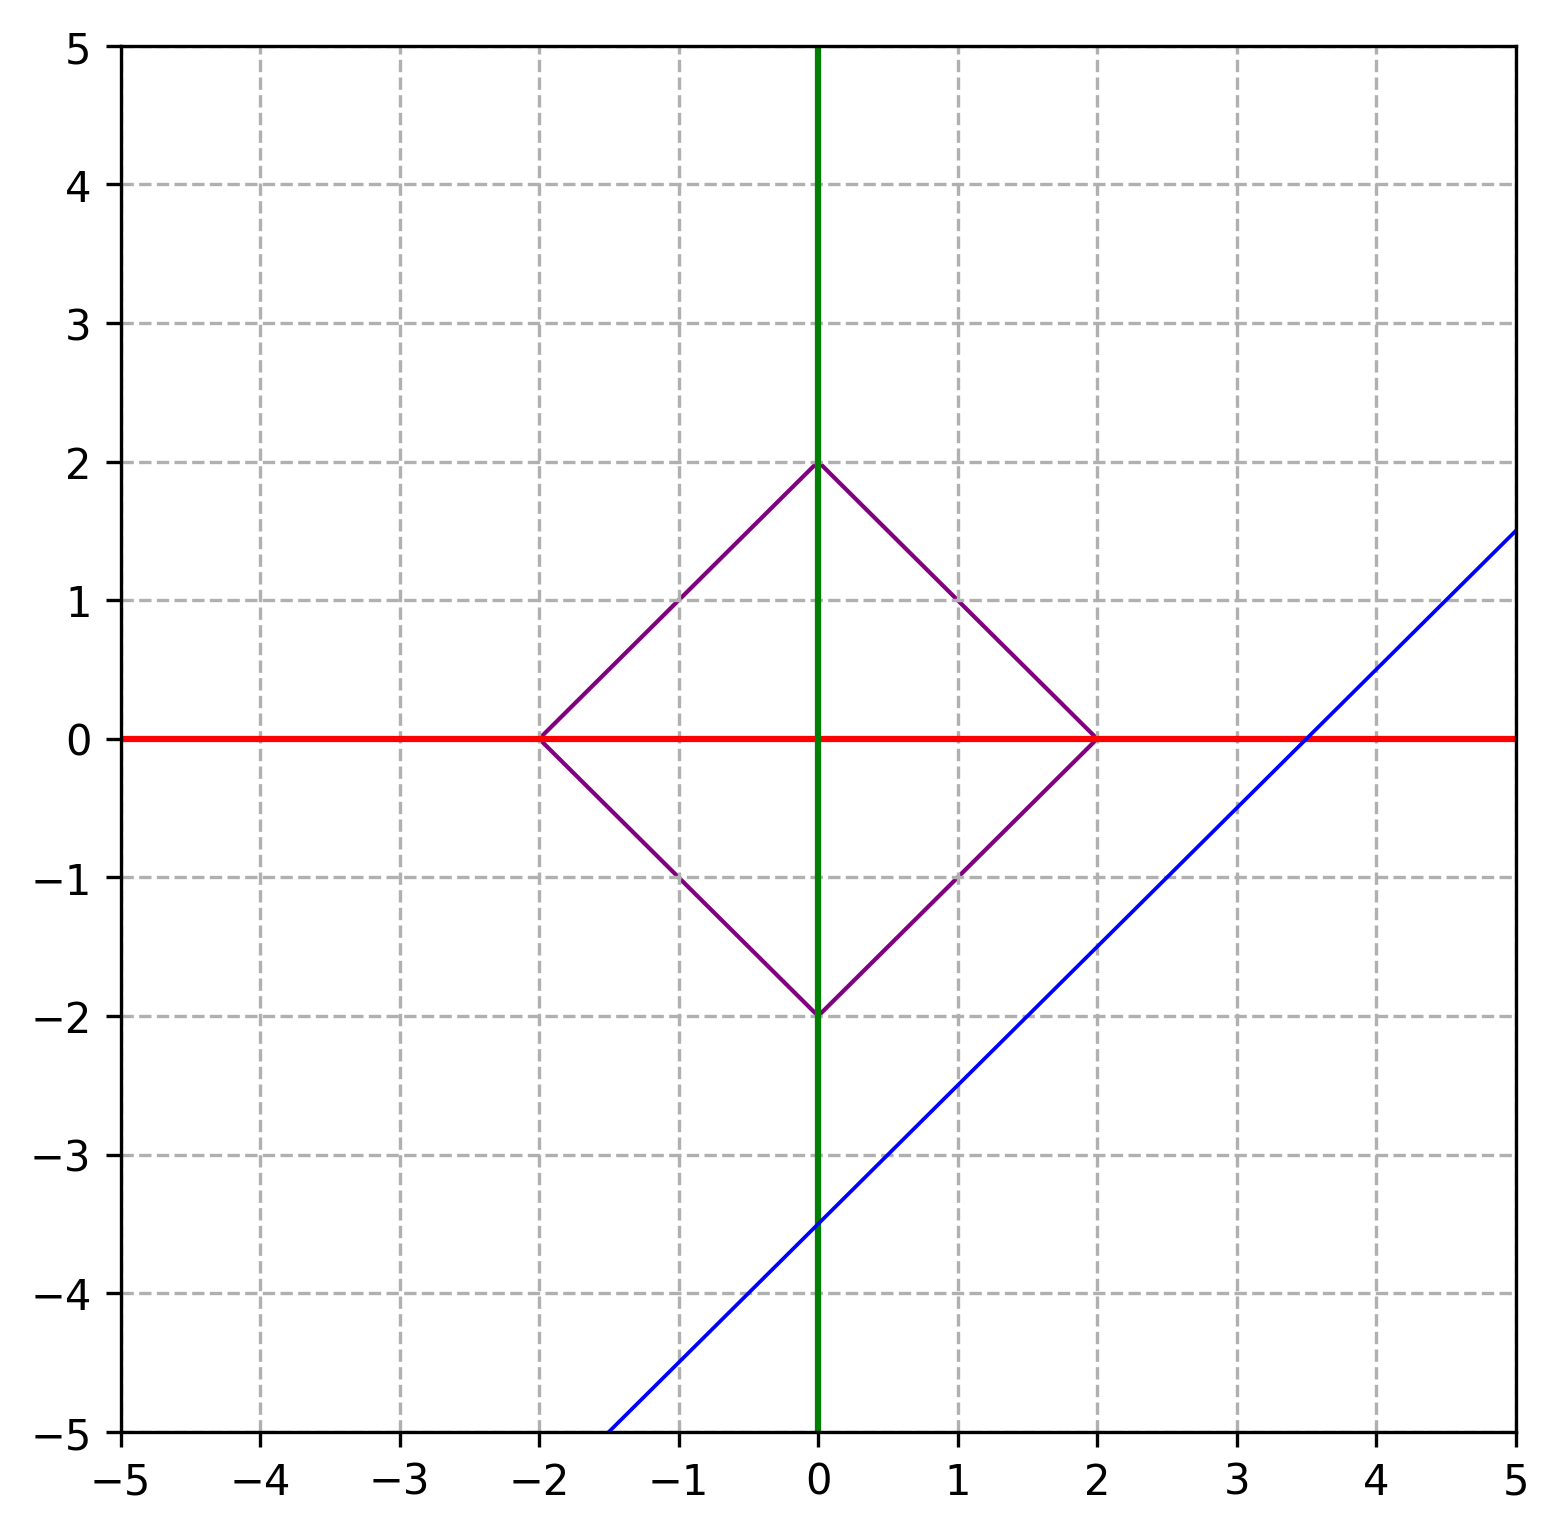

In [51]:
fig01 = plt.figure(num = 3, figsize = (6, 6), dpi = 300)
ax01 = fig01.add_subplot(1, 1, 1)

ax01.grid(True, ls = "--")

ax01.set(xlim = (-5, 5), ylim = (-5, 5))
ax01.set_xticks(np.arange(-5, 6, 1))
ax01.set_yticks(np.arange(-5, 6, 1))

ax01.axline(xy1=(0, 0), xy2=(1, 0), color="red")
ax01.axline(xy1=(0, 0), xy2=(0, 1), color="green")

#vertices.append(vertices[0])
#xs, ys = zip(*vertices)
#ax01.plot(xs,ys, color = "#00BFFF")

r = 2
vertices = mnogoug_prav(4, r)
print(vertices)
ax01.add_patch(mpatches.Polygon(vertices, fill=False, edgecolor='purple'))
a = 0
print(l4.P0)
a = np.sqrt(l4.P0[0] * l4.P0[0] + l4.P0[1] * l4.P0[1])
a = np.abs(a)
print(a)

xs, ys = zip(*vertices)
for x, y in zip(xs, ys):
    qwerty = (l4.a*x+l4.b*y+l4.c)/sqrt(l4.a*l4.a + l4.b*l4.b)
    if -l4.a/l4.b > 0:
        if (a < r):
            if (qwerty < 0):
                ax01.add_patch(mpatches.Polygon(vertices, fill=True, facecolor='pink', edgecolor='purple'))
    if -l4.a/l4.b < 0:
        if (a < r):
            if qwerty > 0:
                ax01.add_patch(mpatches.Polygon(vertices, fill=True, facecolor='pink', edgecolor='purple'))
    if -l4.a/l4.b == 0:
        if(a < r):
            if qwerty < 0:        
                ax01.add_patch(mpatches.Polygon(vertices, fill=True, facecolor='pink', edgecolor='purple'))

ax01.axline(xy1=l4.P0, slope=l4.slope(), color='blue', lw=0.9)
            
plt.show()

In [ ]:
#два квадрата, один пересекает

In [48]:
#5

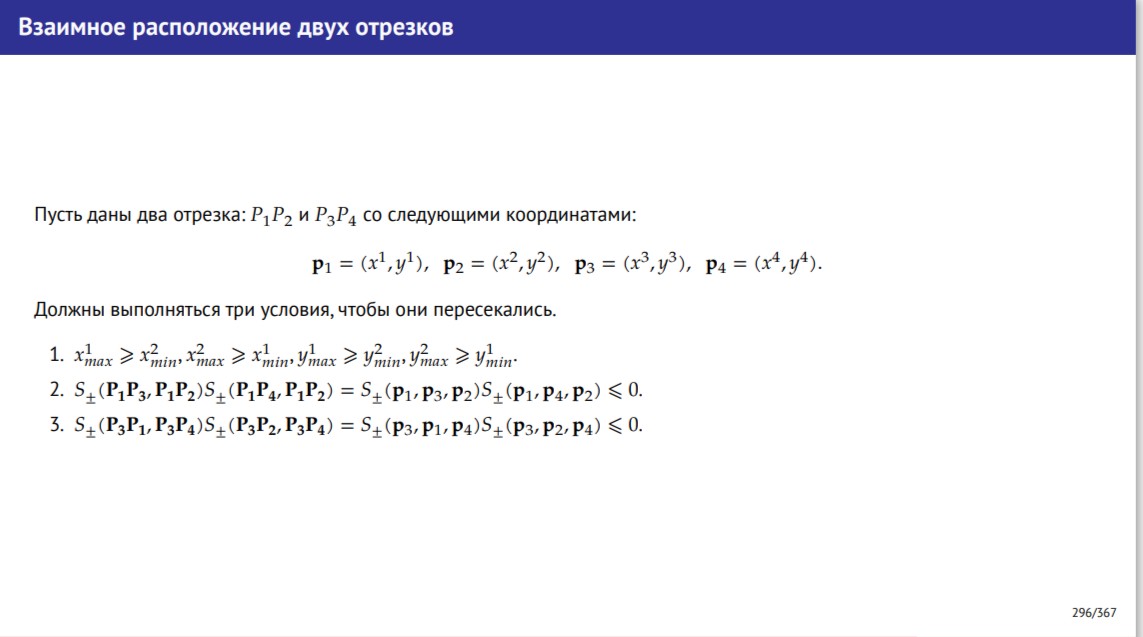

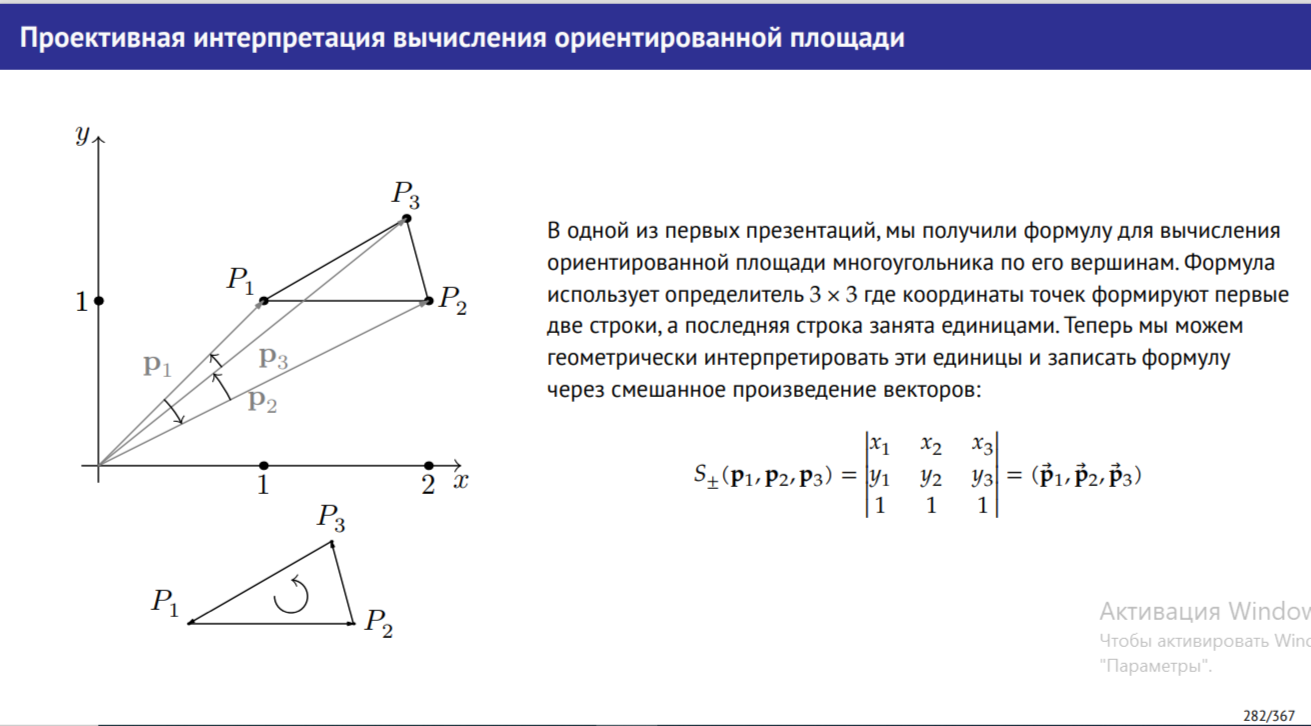

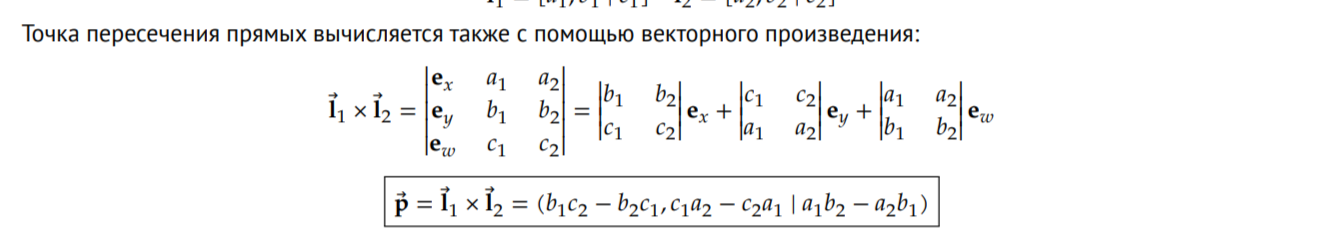

In [903]:
def orientir_square(p1, p2, p3):
    return np.linalg.det(np.array([[p1[0], p2[0], p3[0]],
                                   [p1[1], p2[1], p2[1]],
                                   [1,1,1]]))

Отрезки не пересекаются


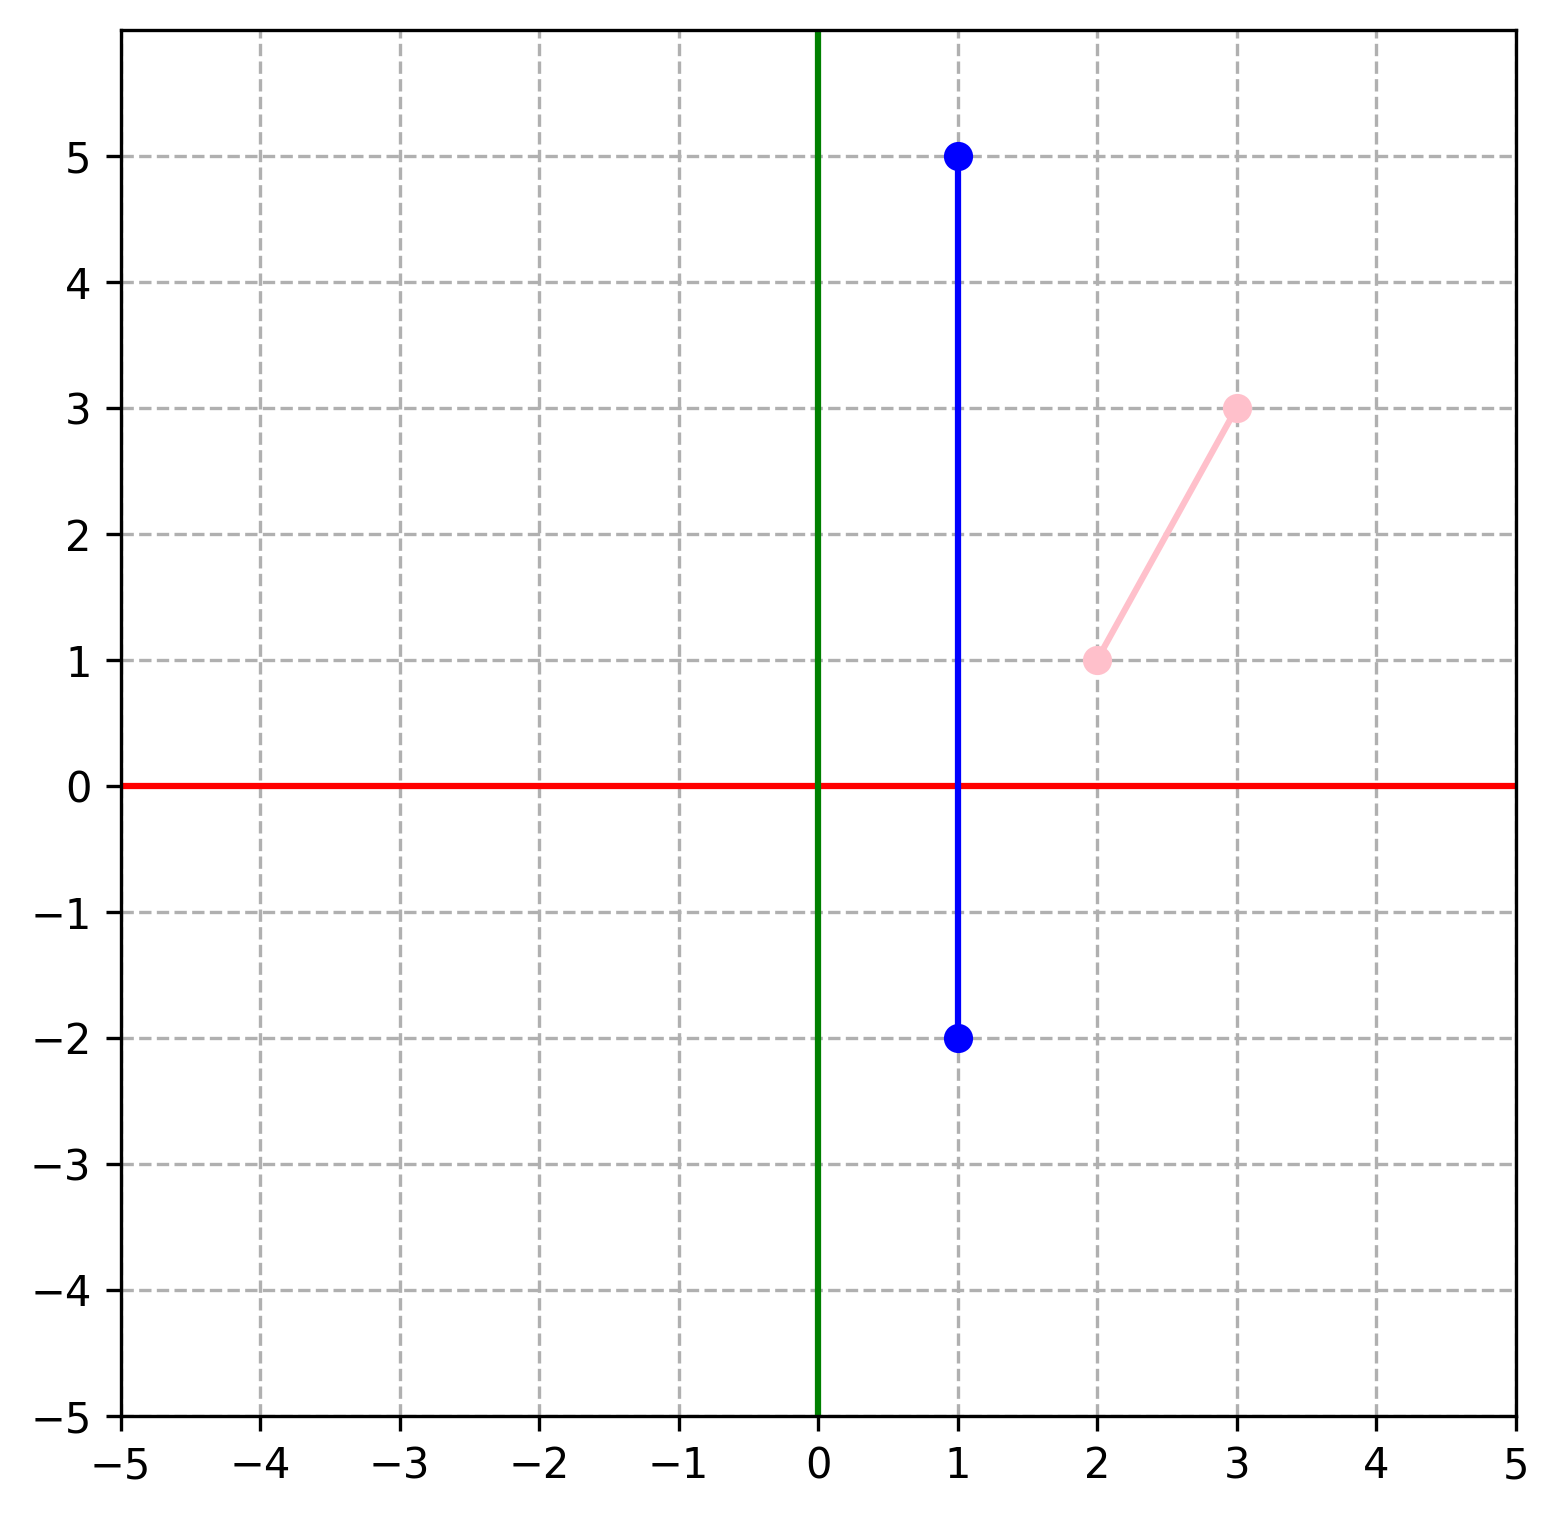

In [52]:
fig01 = plt.figure(num = 4, figsize = (6, 6), dpi = 300)
ax01 = fig01.add_subplot(1, 1, 1)

ax01.grid(True, ls = "--")

ax01.set(xlim = (-5, 5), ylim = (-5, 6))
ax01.set_xticks(np.arange(-5, 6, 1))
ax01.set_yticks(np.arange(-5, 6, 1))

ax01.axline(xy1=(0, 0), xy2=(1, 0), color="red")
ax01.axline(xy1=(0, 0), xy2=(0, 1), color="green")

p1 = (2, 1, 1)
p2 = (3, 3, 1)
p3 = (1, 5, 1)
p4 = (1, -2, 1)

ax01.plot([p1[0],p2[0]], [p1[1], p2[1]], color='pink')
ax01.plot([p3[0],p4[0]], [p3[1], p4[1]], color='blue')
ax01.plot(p1[0], p1[1], 'o', color = 'pink')
ax01.plot(p2[0], p2[1], 'o', color = 'pink')
ax01.plot(p3[0], p3[1], 'o', color = 'blue')
ax01.plot(p4[0], p4[1], 'o', color = 'blue')

if (max(p1[0], p2[0]) >= min(p3[0], p4[0]) and (max(p3[0], p4[0]) >= min(p1[0], p2[0])) and
    max(p1[1], p2[1]) >= min(p3[1], p4[1]) and (max(p3[1], p4[1]) >= min(p1[1], p2[1])) and 
    orientir_square(p1, p3, p2) * orientir_square(p1, p4, p2) <= 0 and 
    orientir_square(p3, p1, p4) * orientir_square(p3, p2, p4) <= 0):
    print('Отрезки пересекаются')
    l1 = Line.from_two_points(p1, p2)
    l2 = Line.from_two_points(p3, p4)
    peres = (l1.b * l2.c - l2.b * l1.c)/(l1.a * l2.b - l2.a * l1.b)
    peres_y = -(l1.b*peres+l1.c)/l1.a
    ax01.plot(peres, peres_y,'ro') 
    print("Точкa пересечения: ", peres, peres_y)
    
else:
    print('Отрезки не пересекаются')

In [905]:
#6

4.0


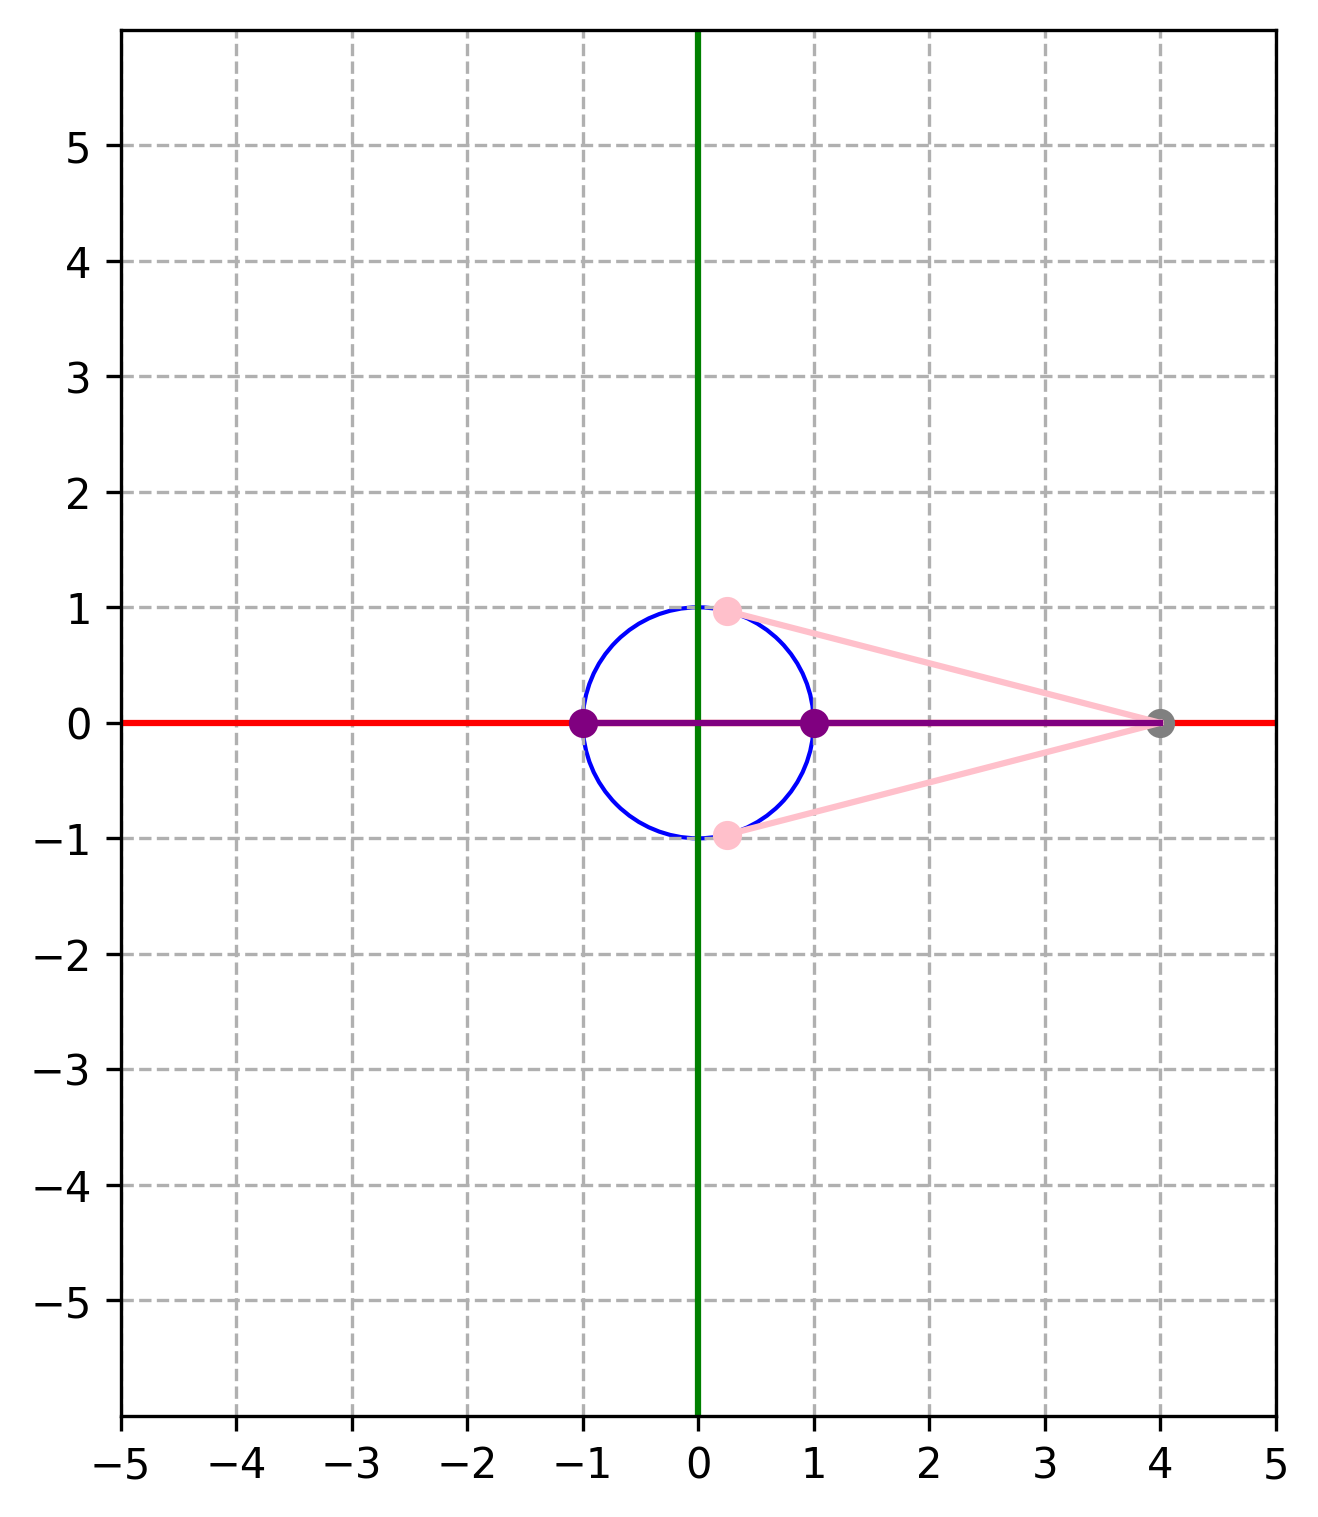

In [906]:
fig01 = plt.figure(num = 5, figsize = (6, 6), dpi = 300)
ax01 = fig01.add_subplot(1, 1, 1)

ax01.grid(True, ls = "--")

ax01.set(xlim = (-5, 5), ylim = (-6, 6))
ax01.set_xticks(np.arange(-5, 6, 1))
ax01.set_yticks(np.arange(-5, 6, 1))

ax01.axline(xy1=(0, 0), xy2=(1, 0), color="red")
ax01.axline(xy1=(0, 0), xy2=(0, 1), color="green")

ax01.set_aspect('equal')

center = (0, 0)
r = 1
circ_r = plt.Circle(center, r, edgecolor='blue', fill = False)
ax01.add_patch(circ_r)

tochka = (4, 0)
ax01.plot(tochka[0], tochka[1], 'o', color = 'gray')

# Расчет дистанции от центра круга до точки
d = np.sqrt((tochka[0] - center[0])**2 + (tochka[1] - center[0])**2)
print(d)

# Расчет углов для касательной
angle = np.arccos(r / d)

# Координаты точек касания круга
x1, y1 = center[0] + r * np.cos(angle), center[1] + r * np.sin(angle)
x2, y2 = center[0] + r * np.cos(-angle), center[1] + r * np.sin(-angle)
ax01.plot([tochka[0], x1], [tochka[1], y1], 'pink') 
ax01.plot([tochka[0], x2], [tochka[1], y2], 'pink') 
ax01.plot(x1, y1, 'o', color = 'pink')
ax01.plot(x2, y2, 'o', color = 'pink')

ax01.plot([tochka[0], -1], [tochka[1], 0], 'purple') 
ax01.plot(1, 0, 'o', color = 'purple')
ax01.plot(-1, 0, 'o', color = 'purple')